# Weight Experimentation for Workflows

The goal of this notebook will be to figure out the optimal weighter for the workflow schedueler on opendc. The optimial weighers will be weighers that optimize makespan in the experiments


### Parameters Being Tested: 
- **weightUrgency** = weight applied to deadline urgency score(Slack-Based) where lower slack indicated higher urgency

- **weightCriticalDependecyChain** = weight applied to Critical Dependency Chain Score which priorizes tasks with deeper dependency structures

- **weightParallelism** = weight applied to Parallelism Expansion where tasks are scored based on how much parallelism they unlock in the future. Only used when needed and tied to **taskLookaheadThreshold**

### Parameters not being tested
- **parallelismDecayRate** = recursive scoring mechanism where each node’s children and deeper descendants contribute to its overall “parallelism score,” but their influence decreases exponentially with depth. The decayRate parameter controls how aggressively their impact fades.

- **subsetSize** = constant
- **taskLookaheadThreshold** = constant
- **enableDeadlineScore** = True
- **enableParallelismScore** = True 





In [23]:
# Import all necessary libraries
import subprocess 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns
from datetime import datetime
from pathlib import Path
import copy

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Paths
BASE_DIR = Path('/DSLab/energyless')
RUNNER_PATH = BASE_DIR / 'OpenDCExperimentRunner/bin/OpenDCExperimentRunner.bat'
EXPERIMENTS_DIR = BASE_DIR / 'wf_scheduler_comparison_experiments'
OUTPUT_DIR = BASE_DIR / 'output'
RESULTS_DIR = EXPERIMENTS_DIR / 'parameter_sweep_results'
RESULTS_DIR.mkdir(exist_ok=True)

print("✅ Environment configured")


✅ Environment configured


# Step 1: Define Parameter Sweep Configurations

In [24]:
# Base Experiment Template
#C:/DSLab/energyless/
# "pathToFile": "input/synthetic_traces/balanced_tree_depth2_branching2_deadline_default",
# random_dag_n25_edge_prob0.12_seed1_deadline_alt
#input\synthetic_traces\real_world_sipht_n200_deadline_default
#input\synthetic_traces\real_world_sipht_n500_deadline_default

BASE_CONFIG = {
  "name": "workflow_aware_sweep",
  "topologies": [
    {"pathToFile": "input/topologies/sample_NL.json"}
  ],
  "workloads": [{
      "pathToFile": "input/synthetic_traces/real_world_sipht_n500_deadline_default",
      "type": "ComputeWorkload"}, 
      {
        "pathToFile": "input/synthetic_traces/real_world_sipht_n200_deadline_default",
        "type": "ComputeWorkload"
      }
  ],
  "allocationPolicies": [{
      "type": "workflowAware",
      "filters": [
        {"type": "Compute" },
        {"type": "VCpu", "allocationRatio": 1.0},
        {"type": "Ram","allocationRatio": 1.0}
      ],
      "weighers": [
        {"type": "Ram","multiplier": 1.0}
      ],
      "enableDeadlineScore": True,
      "enableParallelismScore": True,
      "subsetSize": 1,
      "taskLookaheadThreshold" : 50,
      "parallelismDecayRate": 1.5
    }
  ],
  "exportModels": [{
      "exportInterval": 3600,
      "printFrequency": 24,
      "filesToExport": ["host", "powerSource", "task"]
    }]
}


# Parameter config
SWEEP_CONFIGS = [
    # baseline - no weights
    {"name": "baseline", "weightUrgency" : 0.0, "weightCriticalDependencyChain": 0.0, "weightParallelism": 0.0},

    # Balanced - same weights 
    {"name": "balanced","weightUrgency" : 0.33, "weightCriticalDependencyChain": 0.33, "weightParallelism": 0.33},

    # High Urgency Weight
    {"name": "urgency","weightUrgency" : 10.0, "weightCriticalDependencyChain": 0.2, "weightParallelism": 0.2},

    # High Critical Depedency Chain Weight
    {"name": "critical_dependency_chain","weightUrgency" : 0.2, "weightCriticalDependencyChain": 10.0, "weightParallelism": 0.2},

    # High Parallelism Weight
    {"name": "parallelism","weightUrgency" : 0.2, "weightCriticalDependencyChain": 0.2, "weightParallelism": 10.0},

    # High Urgency and CDC Weight
    {"name": "urgency_and_cdc","weightUrgency" : 10.0, "weightCriticalDependencyChain": 10.0, "weightParallelism": 0.2},

    # High Urgency and Parallelism Weight
    {"name": "urgency_and_parallelism","weightUrgency" : 10.0, "weightCriticalDependencyChain": 0.2, "weightParallelism": 10.0},

    # High CDC and Parallelism Weight
    {"name": "cdc_and_parallelism","weightUrgency" : 0.2, "weightCriticalDependencyChain": 10.0, "weightParallelism": 10.0},
]

print(f"✅ Configured {len(SWEEP_CONFIGS)} parameter combinations to test")
print("\nConfigurations:")
for i, config in enumerate(SWEEP_CONFIGS, 1):
    print(f"{i:2d}. {config['name']}")


✅ Configured 8 parameter combinations to test

Configurations:
 1. baseline
 2. balanced
 3. urgency
 4. critical_dependency_chain
 5. parallelism
 6. urgency_and_cdc
 7. urgency_and_parallelism
 8. cdc_and_parallelism


# Step 2: Helper Functions

In [25]:
def create_experiment_config(config_params):
    """Create experiment JSON with given parameters."""
    config = copy.deepcopy(BASE_CONFIG)
    config["name"] = f"workflow_aware_sweep_{config_params['name']}"
    
    policy = config["allocationPolicies"][0].copy()
    policy.update({
        "weightUrgency": config_params["weightUrgency"],
        "weightCriticalDependencyChain": config_params["weightCriticalDependencyChain"],
        "weightParallelism": config_params["weightParallelism"],
    })
    config["allocationPolicies"][0] = policy
    return config


def run_experiment(config_params, config_num, total_configs):
    """Run a single experiment."""
    config = create_experiment_config(config_params)
    exp_name = config_params['name']
    
    # Save config
    config_file = EXPERIMENTS_DIR  / "" f"wfa_sweep_{exp_name}.json"
    with open(config_file, 'w') as f:
        json.dump(config, f, indent=2)
    
    print(f"\n{'='*80}")
    print(f"Experiment {config_num}/{total_configs}: {exp_name}")
    print(f"{'='*80}")

    # Run experiment
    result = subprocess.run(
        [str(RUNNER_PATH), "--experiment-path", str(config_file)],
        capture_output=True, text=True, shell=False, cwd=str(BASE_DIR) 
    )
    
    if result.returncode != 0:
        print(f"❌ Failed: {result.stderr}")
        return None
    
    print(f"✅ Completed!")
    
    # Parse results
    output_path = OUTPUT_DIR / f"workflow_aware_sweep_{exp_name}" / "raw-output/0/seed=0"
    try:
        return parse_results(output_path, exp_name, config_params)
    except Exception as e:
        print(f"❌ Parse error: {e}")
        return None

def parse_results(output_path, exp_name, config_params):
    """Parse experiment results."""
    power = pd.read_parquet(output_path / "powerSource.parquet")
    task = pd.read_parquet(output_path / "task.parquet")
    host = pd.read_parquet(output_path / "host.parquet")
    
    return {
        'experiment': exp_name,
        'weightUrgency': config_params['weightUrgency'],
        'weightCriticalDependencyChain': config_params['weightCriticalDependencyChain'],
        'weightParallelism': config_params['weightParallelism'],
        'total_carbon_kg': power['carbon_emission'].sum(),
        'total_energy_kwh': power['energy_usage'].sum() / (1000 * 1000),
        'makespan_hours': task['finish_time'].max() / (1000 * 3600),
        'avg_wait_time_hours': task['scheduling_delay'].mean() / (1000 * 3600),
        'max_wait_time_hours': task['scheduling_delay'].max() / (1000 * 3600),
        'completed_tasks': len(task[task['task_state'] == 'COMPLETED']),
        'total_tasks': len(task),
        'avg_cpu_util': host['cpu_utilization'].mean() * 100
    }

print("✅ Helper functions defined")


✅ Helper functions defined


### Step 3: Run Parameter Sweep

⚠️ This will take some time! Each experiment may take a few minutes.

In [26]:
print("🚀 Starting Parameter Sweep...")
print(f"Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

all_metrics = []

for i, config in enumerate(SWEEP_CONFIGS, 1):
    metrics = run_experiment(config, i, len(SWEEP_CONFIGS))
    print(metrics)
    if metrics:
        all_metrics.append(metrics)

# Create results DataFrame
df_results = pd.DataFrame(all_metrics)

# Save results
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
csv_file = RESULTS_DIR / f"sweep_results_{timestamp}.csv"
df_results.to_csv(csv_file, index=False)

print(f"\n{'='*80}")
print(f"✅ Sweep completed at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"✅ Results saved to: {csv_file}")
print(f"{'='*80}")

🚀 Starting Parameter Sweep...
Time: 2025-12-12 18:20:32


Experiment 1/8: baseline
✅ Completed!
{'experiment': 'baseline', 'weightUrgency': 0.0, 'weightCriticalDependencyChain': 0.0, 'weightParallelism': 0.0, 'total_carbon_kg': np.float32(3785.858), 'total_energy_kwh': np.float32(44.30965), 'makespan_hours': np.float64(1.3885583333333333), 'avg_wait_time_hours': np.float64(0.19553163731245923), 'max_wait_time_hours': np.float64(1.3880555555555556), 'completed_tasks': 484, 'total_tasks': 511, 'avg_cpu_util': np.float32(3.7605292e-05)}

Experiment 2/8: balanced
✅ Completed!
{'experiment': 'balanced', 'weightUrgency': 0.33, 'weightCriticalDependencyChain': 0.33, 'weightParallelism': 0.33, 'total_carbon_kg': np.float32(3785.858), 'total_energy_kwh': np.float32(44.30965), 'makespan_hours': np.float64(1.3885583333333333), 'avg_wait_time_hours': np.float64(0.19553163731245923), 'max_wait_time_hours': np.float64(1.3880555555555556), 'completed_tasks': 484, 'total_tasks': 511, 'avg_cpu_util': n

### Step 4: Analyze Results

Sort configuration by markespan to find the best performer

In [27]:
# Sort by makespan
df_sorted = df_results.sort_values('makespan_hours')

print("\n🏆 RANKING BY MAKESPAN HOURS (Lower is Better)")
print("="*100)

display_cols = ['experiment','weightUrgency','weightCriticalDependencyChain','weightParallelism',
                'total_carbon_kg','total_energy_kwh','makespan_hours','avg_wait_time_hours','max_wait_time_hours','completed_tasks','total_tasks','avg_cpu_util']

print(df_sorted[display_cols].to_string(index=False))

# Calculate improvements vs baseline
baseline = df_results[df_results['experiment'] == 'baseline'].iloc[0]

print("\n\n📊 IMPROVEMENTS VS BASELINE")
print("="*100)

for _, row in df_sorted.iterrows():
    if row['experiment'] == 'baseline':
        continue
    
    makespan_chg = ((row['makespan_hours'] - baseline['makespan_hours']) / baseline['makespan_hours']) * 100
    
    print(f"\n{row['experiment']}:")
    print(f"Makespan: {makespan_chg:+.2f}%")


🏆 RANKING BY MAKESPAN HOURS (Lower is Better)
               experiment  weightUrgency  weightCriticalDependencyChain  weightParallelism  total_carbon_kg  total_energy_kwh  makespan_hours  avg_wait_time_hours  max_wait_time_hours  completed_tasks  total_tasks  avg_cpu_util
                 baseline           0.00                           0.00               0.00       3785.85791          44.30965        1.388558             0.195532             1.388056              484          511      0.000038
                 balanced           0.33                           0.33               0.33       3785.85791          44.30965        1.388558             0.195532             1.388056              484          511      0.000038
                  urgency          10.00                           0.20               0.20       3785.85791          44.30965        1.388558             0.195532             1.388056              484          511      0.000038
critical_dependency_chain           0.20 

#### Step 5: Visualizations

KeyError: 'maxDelayHours'

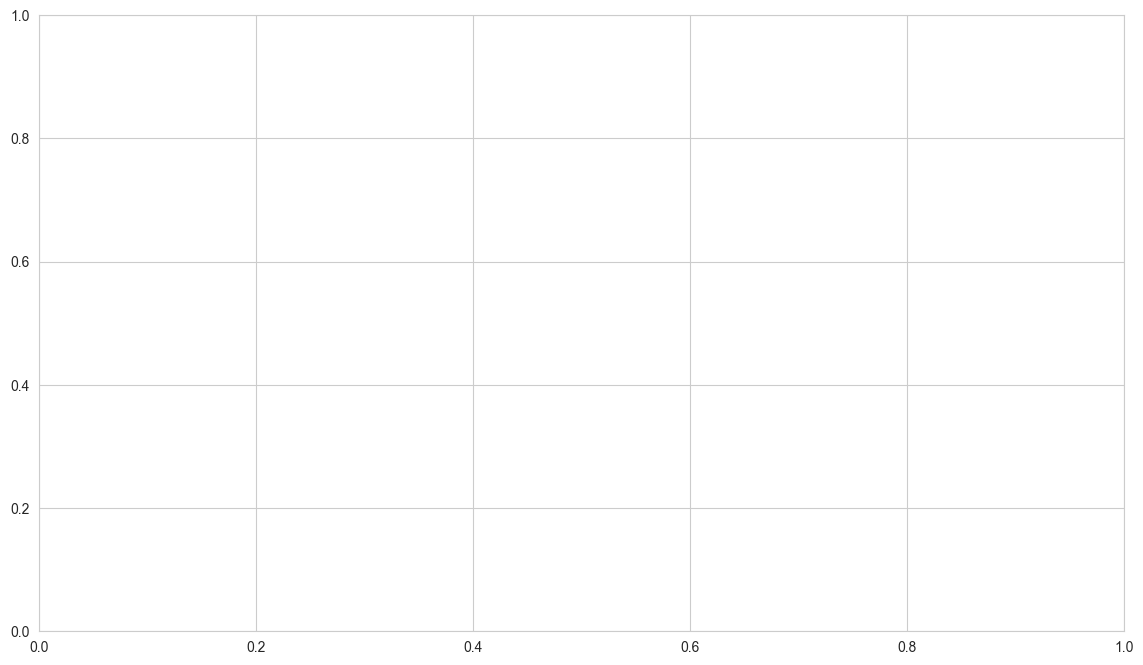

In [36]:
# Carbon vs Makespan tradeoff
fig, ax = plt.subplots(figsize=(14, 8))

scatter = ax.scatter(df_results['total_carbon_kg'], df_results['makespan_hours'],
                     s=200, alpha=0.6, c=df_results['maxDelayHours'], cmap='viridis')

# Annotate points
for _, row in df_results.iterrows():
    ax.annotate(row['experiment'], 
                (row['total_carbon_kg'], row['makespan_hours']),
                fontsize=8, ha='right', va='bottom')

ax.set_xlabel('Total Carbon Emissions (kg CO2)', fontsize=12, weight='bold')
ax.set_ylabel('Makespan (hours)', fontsize=12, weight='bold')
ax.set_title('Carbon vs Makespan Tradeoff\n(Color = Max Delay Hours)', 
             fontsize=14, weight='bold')
plt.colorbar(scatter, ax=ax, label='Max Delay Hours')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

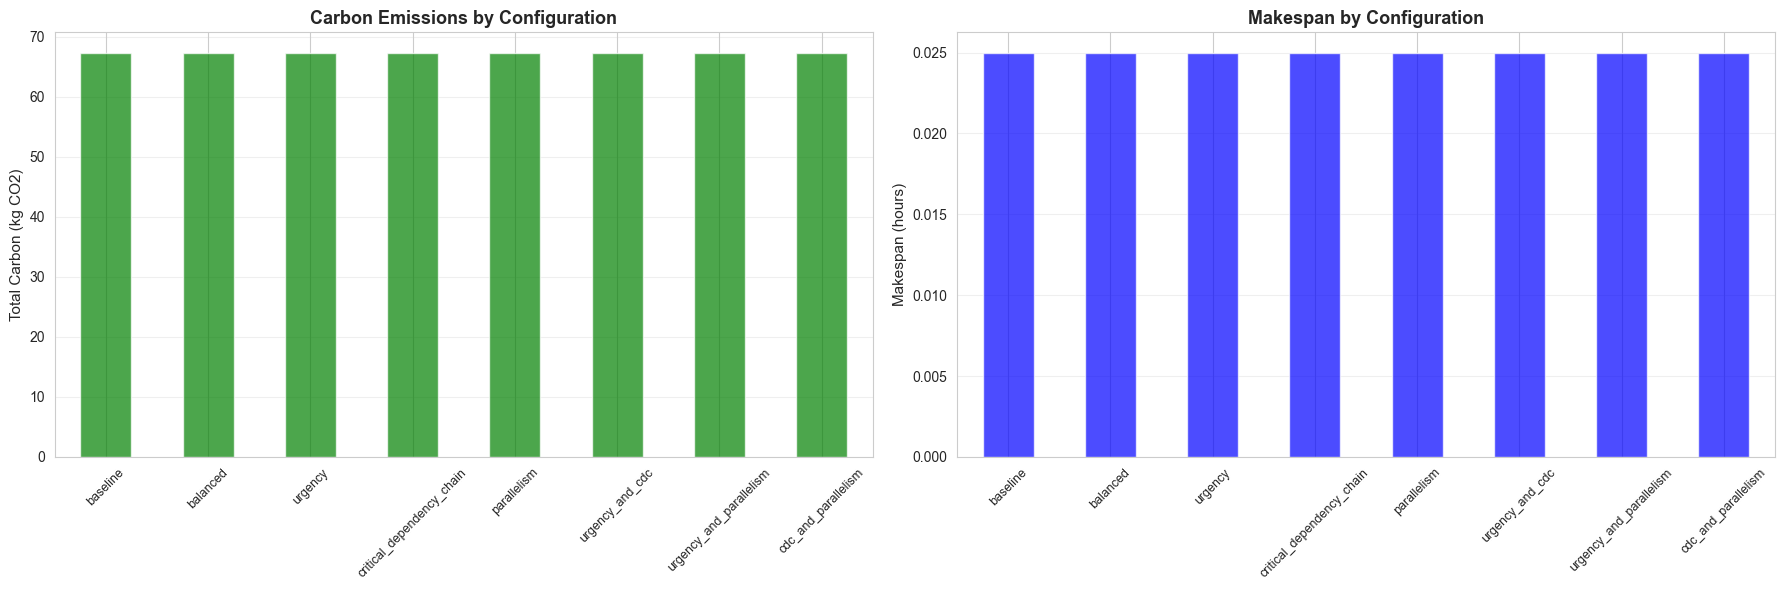

In [25]:

# Bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Carbon emissions
df_sorted.plot(x='experiment', y='total_carbon_kg', kind='bar', ax=ax1, 
               color='green', alpha=0.7, legend=False)
ax1.set_title('Carbon Emissions by Configuration', fontsize=13, weight='bold')
ax1.set_ylabel('Total Carbon (kg CO2)', fontsize=11)
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.grid(axis='y', alpha=0.3)

# Makespan
df_sorted.plot(x='experiment', y='makespan_hours', kind='bar', ax=ax2,
               color='blue', alpha=0.7, legend=False)
ax2.set_title('Makespan by Configuration', fontsize=13, weight='bold')
ax2.set_ylabel('Makespan (hours)', fontsize=11)
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45, labelsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: 'carbonDelayThreshold'

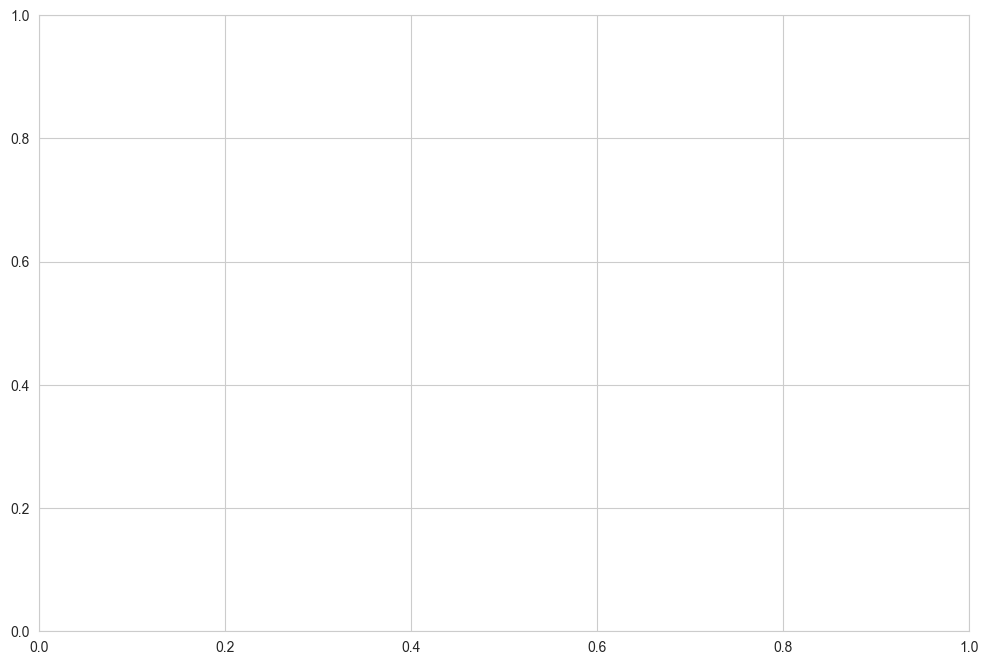

In [26]:
# Heatmap of parameter impact
fig, ax = plt.subplots(figsize=(12, 8))

# Create pivot for heatmap (carbon by threshold and max delay)
pivot_data = df_results.pivot_table(
    values='total_carbon_kg',
    index='carbonDelayThreshold',
    columns='maxDelayHours',
    aggfunc='mean'
)

sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, cbar_kws={'label': 'Carbon (kg)'})
ax.set_title('Carbon Emissions: Threshold vs Max Delay Hours', fontsize=14, weight='bold')
ax.set_xlabel('Max Delay Hours', fontsize=11)
ax.set_ylabel('Carbon Delay Threshold', fontsize=11)
plt.tight_layout()
plt.show()

#### Step 6: Best Configuration Recommendation

In [27]:
best = df_sorted.iloc[0]

print("\n" + "="*80)
print("🏆 RECOMMENDED CONFIGURATION (Lowest Makespan)")
print("="*80)
print(f"\nName: {best['experiment']}")
print(f"\nMetrics:")
print(f"  Makespan: {best['makespan_hours']:.2f} hours")
print(f"  Total Carbon: {best['total_carbon_kg']:.2f} kg CO2")
print(f"  Avg Wait Time: {best['avg_wait_time_hours']:.2f} hours")

makespan_imp = ((baseline['makespan_hours'] - best['makespan_hours']) / baseline['makespan_hours']) * 100
print(f"\n  Carbon Improvement vs Baseline: {makespan_imp:+.2f}%")

print(f"\nOptimal Parameters:")
print(f"  weightUrgency: {best['weightUrgency']}")
print(f"  weightCriticalDependencyChain: {best['weightCriticalDependencyChain']}")
print(f"  weightParallelism: {best['weightParallelism']}")

# Save optimal config
optimal_config = create_experiment_config({
    'name': 'optimal',
    'weightUrgency': best['weightUrgency'],
    'weightCriticalDependencyChain': int(best['weightCriticalDependencyChain']),
    'weightParallelism': int(best['weightParallelism']),
})

optimal_file = EXPERIMENTS_DIR / 'workflow_aware_optimal.json'
with open(optimal_file, 'w') as f:
    json.dump(optimal_config, f, indent=2)

print(f"\n✅ Optimal configuration saved to: {optimal_file}")
print("="*80)
     


🏆 RECOMMENDED CONFIGURATION (Lowest Makespan)

Name: baseline

Metrics:
  Makespan: 0.03 hours
  Total Carbon: 67.35 kg CO2
  Avg Wait Time: 0.01 hours

  Carbon Improvement vs Baseline: +0.00%

Optimal Parameters:
  weightUrgency: 0.0
  weightCriticalDependencyChain: 0.0
  weightParallelism: 0.0

✅ Optimal configuration saved to: \DSLab\energyless\wf_scheduler_comparison_experiments\workflow_aware_optimal.json
